# Data Cleaning - VNExpress News Dataset

Dataset được crawl từ hai chuyên mục:

- Sức khỏe
- Giải trí

Notebook này thực hiện:

1. Kiểm tra dữ liệu thô
2. Làm sạch dữ liệu
3. Chuẩn hóa định dạng
4. Tạo feature mới
5. Xuất dataset sạch để phân tích tiếp

## 1. Import thư viện

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud

sns.set(style="whitegrid")

# Thiết lập để hiển thị biểu đồ đẹp hơn
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14

# Để hiển thị Tiếng Việt đúng
plt.rcParams['font.family'] = 'DejaVu Sans'

pd.set_option("display.max_columns", None)

## 2. Đọc dữ liệu thô

In [135]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv")


## 3. Xử lý dữ liệu thiếu

In [136]:
df_clean = df.copy()

In [137]:
# Hiển thị số lượng giá trị thiếu trước khi xử lý
print("Số lượng giá trị thiếu trước khi xử lý:")

missing_before = df_clean.isnull().sum()
missing_percentage_before = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
pd.DataFrame({
    'Giá Trị Thiếu': missing_before,
    'Phần Trăm (%)': missing_percentage_before
})

Số lượng giá trị thiếu trước khi xử lý:


,Giá Trị Thiếu,Phần Trăm (%)
title,5,0.41
description,2,0.16
date,5,0.41
content,5,0.41
thumbnail,0,0.00
author,0,0.00
tags,0,0.00
group,0,0.00
category,0,0.00
nums_of_comments,0,0.00


In [138]:
df_clean.fillna({
    'title': 'No Title',
    'description': '',
    'category': 'Khác',
    'thumbnail': 'No Image',
    'author': 'Không xác định',
    'content': '',
}, inplace=True)

# Xoá các hàng có giá trị thiếu trong cột 'date' 
df_clean.dropna(subset=['date'], inplace=True)

# Xoá các hàng có giá trị thiếu trong cột 'title' và 'content' 
df = df.dropna(subset=["title", "content"])

print("Rows after removing missing:", len(df))

# Kiểm tra lại sau khi điền giá trị thiếu
print("Số lượng giá trị thiếu sau khi xử lý:")
missing_after = df_clean.isnull().sum()
missing_percentage_after = (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
pd.DataFrame({
    'Giá Trị Thiếu': missing_after,
    'Phần Trăm (%)': missing_percentage_after
})

Rows after removing missing: 1214
Số lượng giá trị thiếu sau khi xử lý:


,Giá Trị Thiếu,Phần Trăm (%)
title,0,0.0
description,0,0.0
date,0,0.0
content,0,0.0
thumbnail,0,0.0
author,0,0.0
tags,0,0.0
group,0,0.0
category,0,0.0
nums_of_comments,0,0.0


## 4. Loại bỏ dữ liệu trùng lặp

In [139]:
print("Rows before:", len(df))

df = df.drop_duplicates(subset="url")

print("Rows after:", len(df))

Rows before: 1214
Rows after: 1214


## 5. Làm sạch dữ liệu văn bản

In [140]:
def clean_text(text):
    if pd.isna(text):
        return ""
        
    # Loại bỏ HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Loại bỏ URL
    text = re.sub(r'http\S+', ' ', text)
    # Loại bỏ ký tự đặc biệt và số
    text = re.sub(r'[^\w\s]', ' ', text)
    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

# Áp dụng hàm làm sạch cho các cột văn bản
df_clean['content_cleaned'] = df_clean['content'].apply(clean_text)
df_clean['description_cleaned'] = df_clean['description'].apply(clean_text)
df_clean['title_cleaned'] = df_clean['title'].apply(clean_text)

# Kiểm tra độ dài của các cột văn bản trước và sau khi làm sạch
df_clean['content_length'] = df_clean['content'].apply(len)
df_clean['description_length'] = df_clean['description'].apply(len)
df_clean['title_length'] = df_clean['title'].apply(len)

# Tính độ dài sau khi làm sạch
df_clean['content_cleaned_length'] = df_clean['content_cleaned'].apply(len)
df_clean['description_cleaned_length'] = df_clean['description_cleaned'].apply(len)
df_clean['title_cleaned_length'] = df_clean['title_cleaned'].apply(len)

In [141]:
# So sánh độ dài trước và sau khi làm sạch
comparison = pd.DataFrame({
    'Tiêu đề (Trước)': df_clean['title_length'].describe(),
    'Tiêu đề (Sau)': df_clean['title_cleaned_length'].describe(),
    'Mô tả (Trước)': df_clean['description_length'].describe(),
    'Mô tả (Sau)': df_clean['description_cleaned_length'].describe(),
    'Nội dung (Trước)': df_clean['content_length'].describe(),
    'Nội dung (Sau)': df_clean['content_cleaned_length'].describe()
}).round(2)

comparison

,Tiêu đề (Trước),Tiêu đề (Sau),Mô tả (Trước),Mô tả (Sau),Nội dung (Trước),Nội dung (Sau)
count,1214.00,1214.00,1214.00,1214.00,1214.00,1214.00
mean,45.00,44.22,132.99,128.57,2832.43,2753.11
std,10.89,10.66,24.47,24.14,1339.40,1299.44
min,16.00,16.00,72.00,71.00,7.00,7.00
25%,38.00,37.00,116.00,112.00,2030.00,1976.75
50%,44.00,44.00,131.00,126.00,2542.00,2470.50
75%,52.00,51.00,147.00,142.00,3303.50,3200.75
max,80.00,79.00,227.00,220.00,10157.00,9842.00


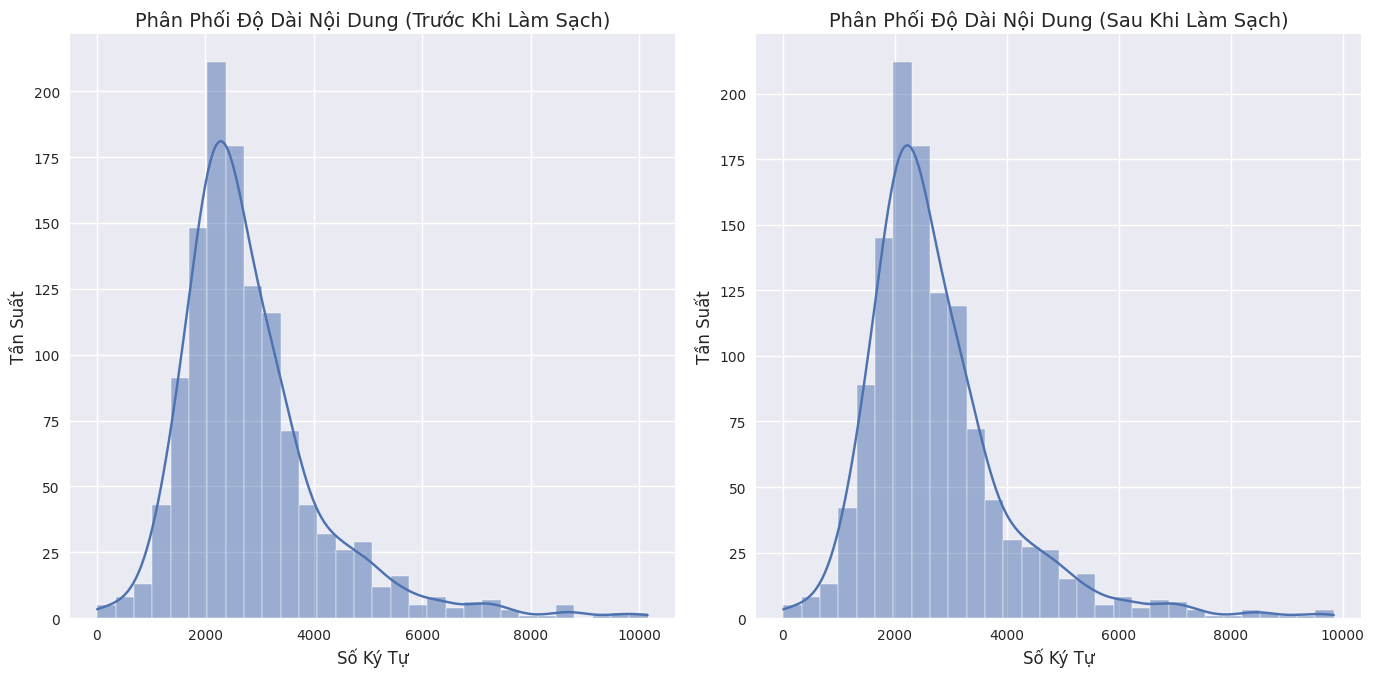

In [142]:
# Trực quan hóa sự thay đổi trước và sau khi làm sạch cho độ dài nội dung
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.histplot(data=df_clean['content_length'], kde=True, bins=30)
plt.title('Phân Phối Độ Dài Nội Dung (Trước Khi Làm Sạch)', fontsize=14)
plt.xlabel('Số Ký Tự', fontsize=12)
plt.ylabel('Tần Suất', fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(data=df_clean['content_cleaned_length'], kde=True, bins=30)
plt.title('Phân Phối Độ Dài Nội Dung (Sau Khi Làm Sạch)', fontsize=14)
plt.xlabel('Số Ký Tự', fontsize=12)
plt.ylabel('Tần Suất', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Chuẩn hóa group/category

In [143]:


def normalize_category(row):
    group = row["group"]
    category = row["category"]

    # Trường hợp crawler lấy được: Các bệnh > Hô hấp

    # Nếu muốn làm theo hướng gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    # if group == "Các bệnh":
    #     group = "Sức khỏe"
    #     category = "Các bệnh"

    # Nếu muốn giữ nguyên các nhóm riêng biệt, nhưng vẫn gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    if group == "Các bệnh":
        group = "Sức khỏe"

    return pd.Series([group, category])


df_clean[["group", "category"]] = df_clean.apply(normalize_category, axis=1)

# print("Unique groups:", df_clean["group"].unique())
# print("Unique categories:", df_clean["category"].unique())

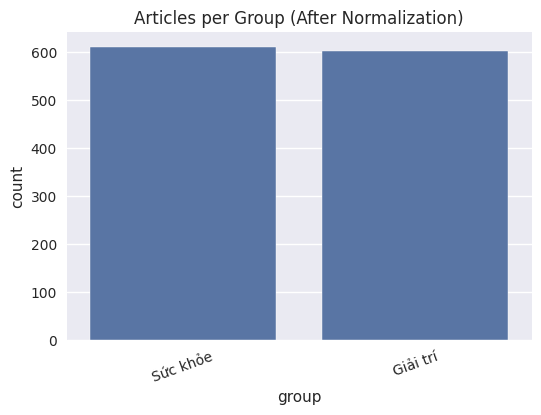

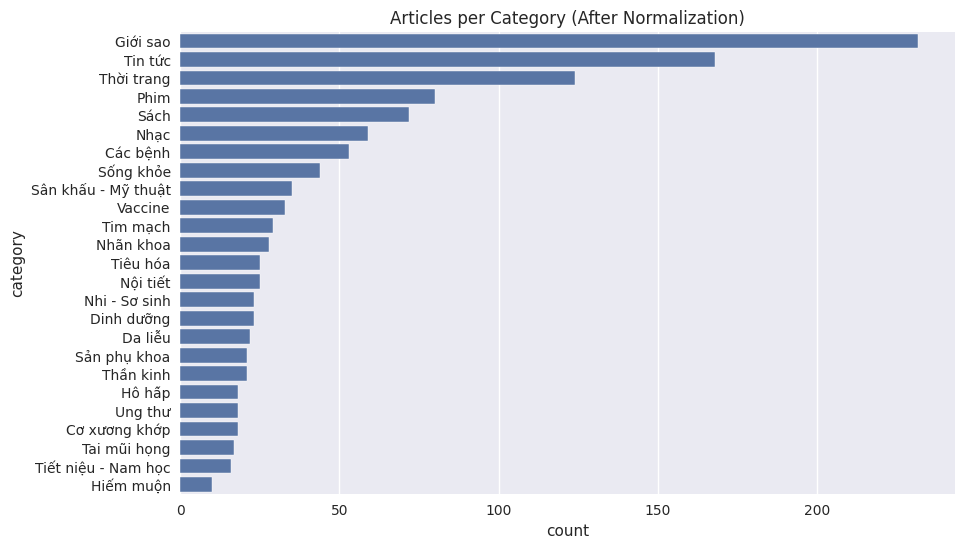

In [144]:
# Visualize group distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="group")
plt.title("Articles per Group (After Normalization)")
plt.xticks(rotation=20)
plt.show()


# Visualize category distribution

plt.figure(figsize=(10,6))
sns.countplot(data=df_clean, y="category", order=df_clean["category"].value_counts().index)
plt.title("Articles per Category (After Normalization)")

plt.show()

## 7. Chuyển đổi kiểu dữ liệu
### Tags: String -> List, Xử lý Author bị lỗi khi thu nhập

In [145]:
# Xử lý cột tags
df_clean['tags_list'] =  df_clean['tags'].str.split(',').apply(lambda x: [tag.strip() for tag in x])
df_clean['tags_count'] = df_clean['tags_list'].apply(len)

print("Số lượng tags trung bình mỗi bài viết:", df_clean['tags_count'].mean())
print("Số lượng tác giả trước khi làm sạch:", df_clean['author'].nunique())
# Xử lý cột author (loại bỏ phần trong ngoặc)
df_clean['author_cleaned'] = df_clean['author'].apply(lambda x: re.sub(r'\s*\(.*?\)', '', str(x)).strip())
# loại bỏ các ký tự không cần thiết 
df_clean['author_cleaned'] = df_clean['author_cleaned'].apply(lambda x: re.sub(r'[^\w\s]', '', str(x)).strip())

print("Số lượng tags trung bình mỗi bài viết:", df_clean['tags_count'].mean())
print("Số lượng tác giả khác nhau sau khi làm sạch:", df_clean['author_cleaned'].nunique())

Số lượng tags trung bình mỗi bài viết: 3.442339373970346
Số lượng tác giả trước khi làm sạch: 251
Số lượng tags trung bình mỗi bài viết: 3.442339373970346
Số lượng tác giả khác nhau sau khi làm sạch: 249


## 8. Chuyển đổi kiểu dữ liệu
### Chuẩn hóa dữ liệu thời gian

In [146]:
# Chuẩn hóa cột ngày tháng
df_clean['date_clean'] = df_clean['date'].str.split(', ', n=1).str[1]
df_clean['date'] = pd.to_datetime(df_clean['date_clean'], format='%d/%m/%Y, %H:%M (GMT+7)', errors='coerce')

# Tạo các đặc trưng thời gian
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day'] = df_clean['date'].dt.day
df_clean['hour'] = df_clean['date'].dt.hour
df_clean['day_of_week'] = df_clean['date'].dt.dayofweek  # 0 là Monday, 6 là Sunday

# Kiểm tra giá trị null sau khi chuyển đổi
print(f"Số lượng giá trị ngày tháng hợp lệ: {df_clean['date'].notnull().sum()} ({df_clean['date'].notnull().sum()/len(df_clean)*100:.2f}%)")
print(f"Số lượng giá trị ngày tháng không hợp lệ: {df_clean['date'].isnull().sum()} ({df_clean['date'].isnull().sum()/len(df_clean)*100:.2f}%)")

Số lượng giá trị ngày tháng hợp lệ: 1214 (100.00%)
Số lượng giá trị ngày tháng không hợp lệ: 0 (0.00%)


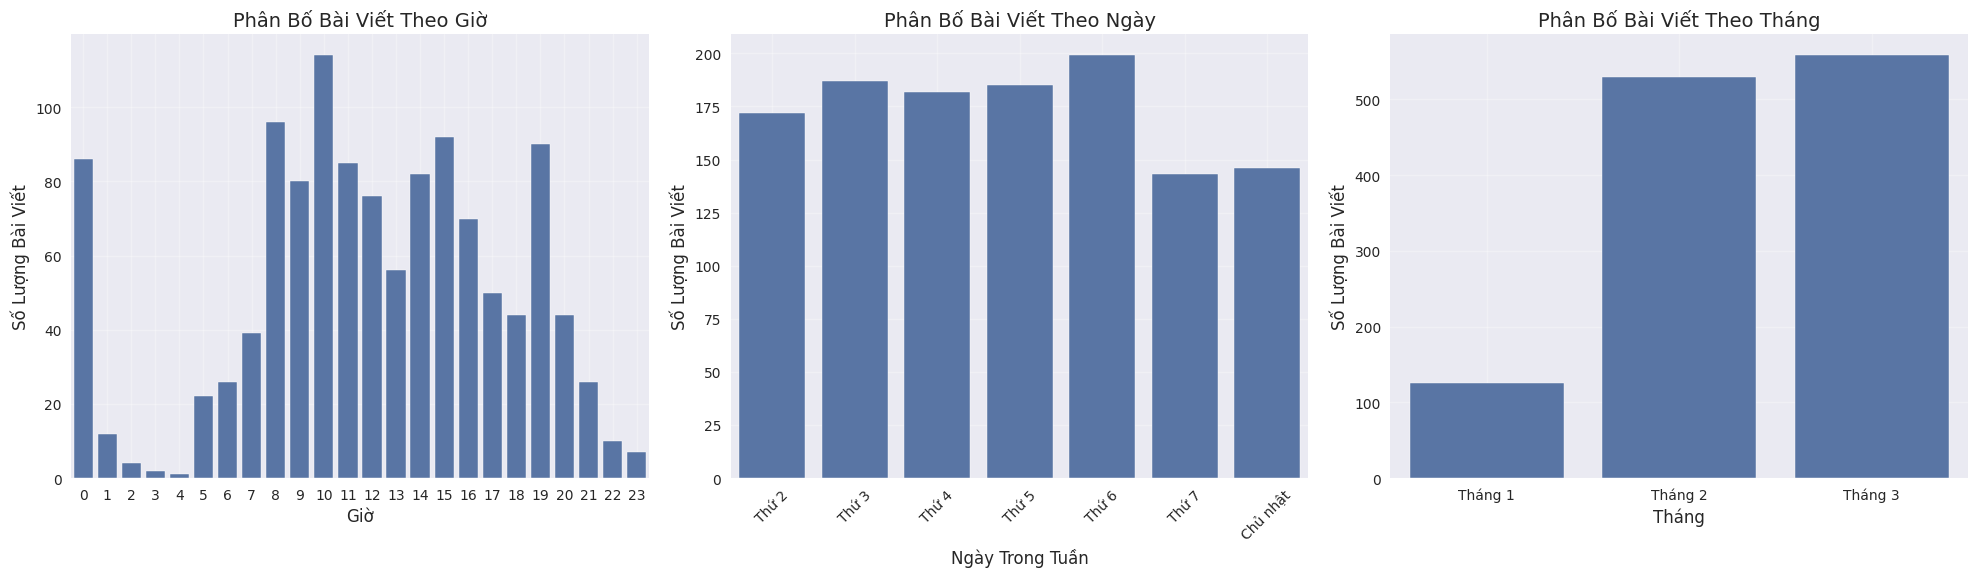

In [147]:
# Tạo figure với 3 subplot nằm ngang
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Biểu đồ phân bố theo giờ trong ngày
hour_counts = df_clean['hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=axes[0])
axes[0].set_title('Phân Bố Bài Viết Theo Giờ', fontsize=14)
axes[0].set_xlabel('Giờ', fontsize=12)
axes[0].set_ylabel('Số Lượng Bài Viết', fontsize=12)
axes[0].set_xticks(range(len(hour_counts)))
axes[0].set_xticklabels([f'{h}' for h in hour_counts.index])
axes[0].grid(True, alpha=0.3)

# 2. Biểu đồ phân bố theo ngày trong tuần
days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ nhật']
day_counts = df_clean['day_of_week'].value_counts().sort_index()
sns.barplot(x=day_counts.index, y=day_counts.values, ax=axes[1])
axes[1].set_title('Phân Bố Bài Viết Theo Ngày', fontsize=14)
axes[1].set_xlabel('Ngày Trong Tuần', fontsize=12)
axes[1].set_ylabel('Số Lượng Bài Viết', fontsize=12)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days, rotation=45)
axes[1].grid(True, alpha=0.3)

# 3. Biểu đồ phân bố theo tháng
month_counts = df_clean['month'].value_counts().sort_index()
sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[2])
axes[2].set_title('Phân Bố Bài Viết Theo Tháng', fontsize=14)
axes[2].set_xlabel('Tháng', fontsize=12)
axes[2].set_ylabel('Số Lượng Bài Viết', fontsize=12)
axes[2].set_xticks(range(len(month_counts)))
axes[2].set_xticklabels([f'Tháng {m}' for m in month_counts.index])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

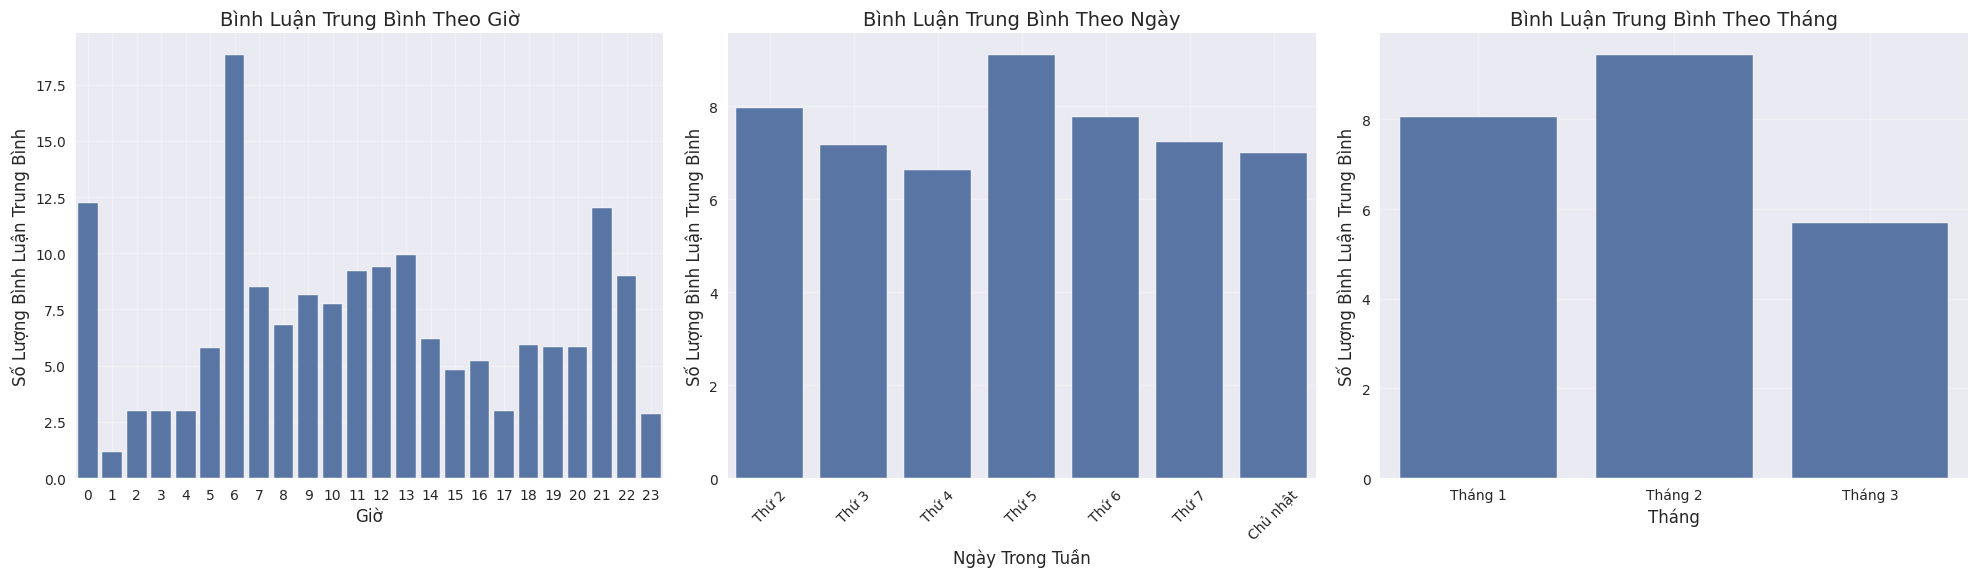

In [148]:
# Tạo biểu đồ phân bố bình luận trung bình theo giờ, ngày và tháng
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Biểu đồ phân bố bình luận trung bình theo giờ
comments_by_hour = df_clean.groupby('hour')['nums_of_comments'].mean().sort_index()
sns.barplot(x=comments_by_hour.index, y=comments_by_hour.values, ax=axes[0])
axes[0].set_title('Bình Luận Trung Bình Theo Giờ', fontsize=14)
axes[0].set_xlabel('Giờ', fontsize=12)
axes[0].set_ylabel('Số Lượng Bình Luận Trung Bình', fontsize=12)
axes[0].set_xticks(range(len(comments_by_hour)))
axes[0].set_xticklabels([f'{h}' for h in comments_by_hour.index])
axes[0].grid(True, alpha=0.3)

# 2. Biểu đồ phân bố bình luận theo ngày trong tuần
comments_by_day = df_clean.groupby('day_of_week')['nums_of_comments'].mean().sort_index()
days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ nhật']
sns.barplot(x=comments_by_day.index, y=comments_by_day.values, ax=axes[1])
axes[1].set_title('Bình Luận Trung Bình Theo Ngày', fontsize=14)
axes[1].set_xlabel('Ngày Trong Tuần', fontsize=12)
axes[1].set_ylabel('Số Lượng Bình Luận Trung Bình', fontsize=12)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days, rotation=45)
axes[1].grid(True, alpha=0.3)

# 3. Biểu đồ phân bố bình luận theo tháng
comments_by_month = df_clean.groupby('month')['nums_of_comments'].mean().sort_index()
sns.barplot(x=comments_by_month.index, y=comments_by_month.values, ax=axes[2])
axes[2].set_title('Bình Luận Trung Bình Theo Tháng', fontsize=14)
axes[2].set_xlabel('Tháng', fontsize=12)
axes[2].set_ylabel('Số Lượng Bình Luận Trung Bình', fontsize=12)
axes[2].set_xticks(range(len(comments_by_month)))
axes[2].set_xticklabels([f'Tháng {m}' for m in comments_by_month.index])
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [149]:
# --- 1. Tiền xử lý Dữ liệu ---
from collections import Counter

# Sao chép để tránh thay đổi DataFrame gốc
df_processed = df_clean.copy()

# --- 1a. Xử lý Cột Ngày tháng ('date_clean') ---
print("Đang xử lý cột ngày tháng...")
datetime_column_name = 'date_parsed'
try:
    date_series = df_processed['date_clean'].astype(str).str.split(r'\s+\(', expand=True)[0]
    df_processed[datetime_column_name] = pd.to_datetime(date_series, format='%d/%m/%Y, %H:%M', errors='coerce')
except KeyError:
     raise KeyError("Lỗi: Không tìm thấy cột 'date_clean'.")
except Exception as e:
    print(f"Lỗi khi xử lý ngày tháng: {e}. Kiểm tra định dạng.")

nat_count = df_processed[datetime_column_name].isnull().sum()
if nat_count > 0:
    print(f"CẢNH BÁO: Loại bỏ {nat_count} hàng có ngày tháng không hợp lệ.")
    df_processed = df_processed.dropna(subset=[datetime_column_name])
if df_processed.empty:
    raise ValueError("DataFrame trống sau khi loại bỏ ngày tháng không hợp lệ.")
print("Xử lý ngày tháng hoàn tất.")

# --- 1b. Xử lý Cột Comments ('nums_of_comments') ---
if 'nums_of_comments' not in df_processed.columns:
    raise ValueError("Lỗi: DataFrame thiếu cột 'nums_of_comments'.")
df_processed['nums_of_comments'] = pd.to_numeric(df_processed['nums_of_comments'], errors='coerce').fillna(0).astype(int)

# --- 1c. Xử lý và Mã hóa Cột Tags ('tags_list') THEO TOKEN CÓ NGHĨA ---
print("Đang xử lý và mã hóa tags theo token có nghĩa...")
if 'tags_list' not in df_processed.columns:
    raise ValueError("Lỗi: DataFrame thiếu cột 'tags_list'.")

def clean_tag(tag):
    """Làm sạch một tag đơn lẻ."""
    if not isinstance(tag, str):
        tag = str(tag)
    # Bỏ khoảng trắng thừa, -> lowercase, bỏ ký tự đặc biệt đơn giản (giữ lại dấu -)
    cleaned = re.sub(r'[^\w\s-]', '', tag.strip().lower())
    return cleaned if cleaned else None # Trả về None nếu tag rỗng sau khi làm sạch

def process_row_tags(tags_data):
    """Làm sạch danh sách các tag trong một hàng."""
    if isinstance(tags_data, list):
        cleaned_list = [clean_tag(tag) for tag in tags_data]
        # Loại bỏ các giá trị None (tag rỗng)
        return [tag for tag in cleaned_list if tag]
    # Xử lý trường hợp tags_list là chuỗi (ví dụ: 'tag1, tag2')
    elif isinstance(tags_data, str):
        tags_list_from_str = tags_data.split(',') # Hoặc dấu phân cách khác nếu cần
        cleaned_list = [clean_tag(tag) for tag in tags_list_from_str]
        return [tag for tag in cleaned_list if tag]
    return [] # Trả về list rỗng nếu không phải list/str hoặc là NaN

# Áp dụng hàm xử lý cho từng hàng để có danh sách các tag đã làm sạch
df_processed['tags_cleaned_list'] = df_processed['tags_list'].apply(process_row_tags)

# --- Đếm tần suất và chọn Top N Tags ---
# Flatten danh sách các tag từ tất cả các hàng
all_tags_flat = [tag for sublist in df_processed['tags_cleaned_list'] for tag in sublist]

if not all_tags_flat:
    print("Cảnh báo: Không tìm thấy tag nào hợp lệ trong cột 'tags_list'.")
    encoded_tag_columns = []
    df_final = df_processed.copy() # Không có cột tag nào được thêm
else:
    # Đếm tần suất
    tag_counts = Counter(all_tags_flat)

    # Chọn Top N tag phổ biến nhất
    num_top_tags = 15
    # Lấy tag và số lần xuất hiện, sắp xếp giảm dần
    most_common_tags = tag_counts.most_common(num_top_tags)
    top_tags_list = [tag for tag, count in most_common_tags] # Chỉ lấy tên tag

    if not top_tags_list:
        print("Cảnh báo: Không xác định được tag phổ biến nào.")
        encoded_tag_columns = []
        df_final = df_processed.copy()
    else:
        print(f"Top {len(top_tags_list)} tags phổ biến nhất: {top_tags_list}")

        # --- Mã hóa One-Hot cho Top N Tags ---
        df_final = df_processed.copy() # Bắt đầu từ df_processed
        encoded_tag_columns = [] # Lưu tên các cột tag đã tạo

        for tag in top_tags_list:
            col_name = f"tag_{tag.replace(' ', '_')}" # Tạo tên cột hợp lệ
            encoded_tag_columns.append(col_name)
            # Kiểm tra sự hiện diện của tag trong 'tags_cleaned_list' của mỗi hàng
            df_final[col_name] = df_final['tags_cleaned_list'].apply(lambda tag_list: 1 if tag in tag_list else 0)

        print(f"Đã tạo {len(encoded_tag_columns)} cột mã hóa one-hot cho các tags.")

Đang xử lý cột ngày tháng...
Xử lý ngày tháng hoàn tất.
Đang xử lý và mã hóa tags theo token có nghĩa...
Top 15 tags phổ biến nhất: ['tp hcm', 'hà nội', 'vaccine', 'trung quốc', 'ung thư', 'giảm cân', 'dinh dưỡng', 'bệnh tim mạch', 'tiêm chung', 'phong bênh', 'ngộ độc thực phẩm', 'trấn thành', 'hòa minzy', 'tết bính ngọ', 'mỹ']
Đã tạo 15 cột mã hóa one-hot cho các tags.


Đang tổng hợp dữ liệu theo week_start...
Tổng hợp dữ liệu theo week_start hoàn tất.
Đang tổng hợp dữ liệu theo month_start...
Tổng hợp dữ liệu theo month_start hoàn tất.
Đang chuẩn bị vẽ biểu đồ 3D theo Tuần (Ngày bắt đầu)...
Đang hiển thị biểu đồ 3D theo Tuần (Ngày bắt đầu)...


/var/folders/kl/wl9qbcgd7d199zkz7dg9x6sc0000gn/T/ipykernel_92518/2809298743.py:100: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('turbo', num_tags_plot)


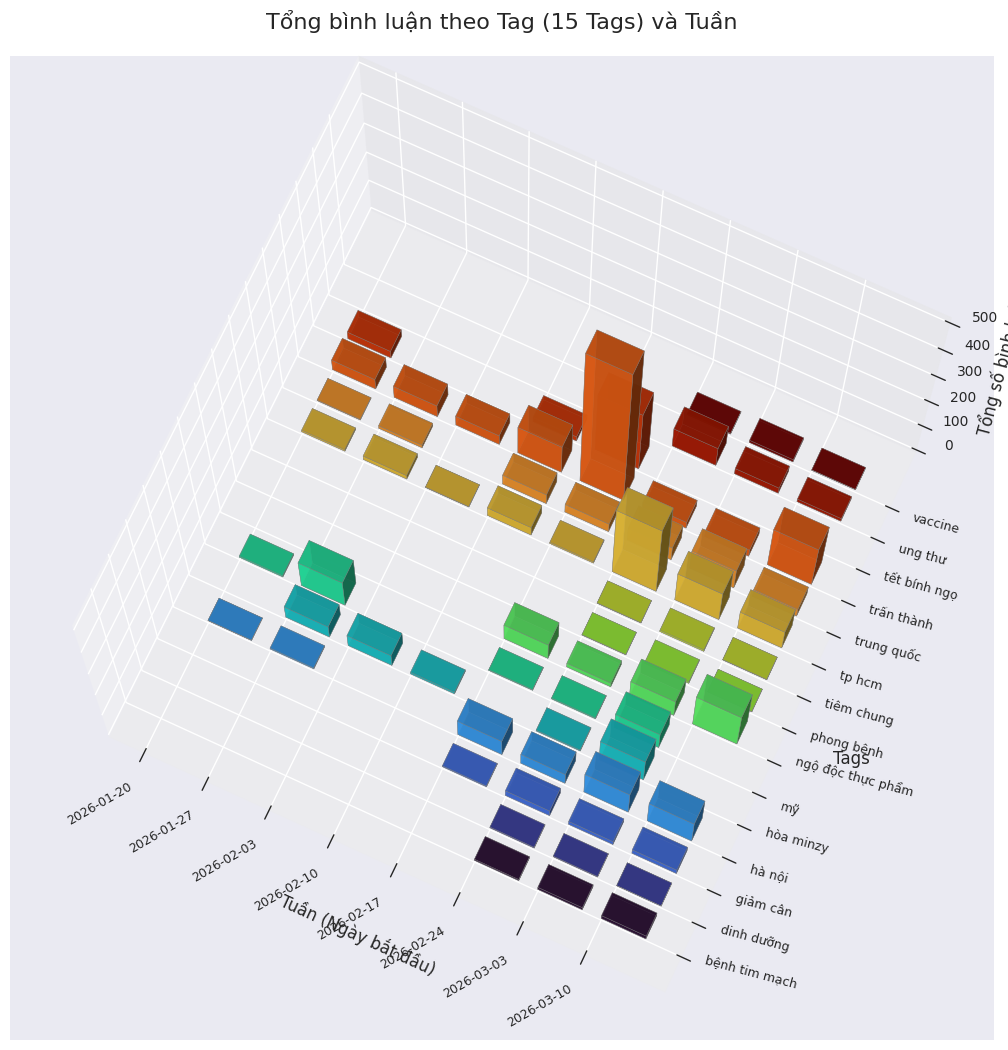

Hoàn thành!


In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates
# from sklearn.feature_extraction.text import CountVectorizer # Không cần nữa
import re
from collections import Counter # Sử dụng Counter để đếm tần suất

# --- 2. Chuẩn bị Dữ liệu cho Vẽ Biểu đồ ---
def aggregate_for_3d(df, time_col_name, encoded_tags, comment_col='nums_of_comments'):
    """Gom nhóm dữ liệu theo thời gian và tag để vẽ 3D."""
    print(f"Đang tổng hợp dữ liệu theo {time_col_name}...")
    if time_col_name not in df.columns:
        print(f"Cảnh báo: Thiếu cột thời gian {time_col_name}.")
        return pd.DataFrame()
    if not encoded_tags:
         print("Không có cột tag nào để tổng hợp.")
         return pd.DataFrame()

    aggregated_data = []
    # Kiểm tra xem df có cột để group không
    if time_col_name not in df:
        print(f"Lỗi: Cột '{time_col_name}' không tồn tại trong DataFrame để gom nhóm.")
        return pd.DataFrame()

    grouped = df.groupby(time_col_name)

    for period_start, group in grouped:
        for tag_col in encoded_tags:
            if tag_col not in group.columns:
                continue
            rows_with_tag = group[group[tag_col] > 0]
            total_comments = rows_with_tag[comment_col].sum()
            if total_comments > 0:
                aggregated_data.append({
                    'time_period': period_start,
                    'tag_name': tag_col.replace('tag_', '').replace('_', ' '), # Tên tag sạch
                    'total_comments': total_comments
                })
    result_df = pd.DataFrame(aggregated_data)
    if result_df.empty:
        print(f"Không tìm thấy dữ liệu bình luận nào liên quan đến các tag đã mã hóa khi nhóm theo {time_col_name}.")
    else:
         print(f"Tổng hợp dữ liệu theo {time_col_name} hoàn tất.")
    return result_df

# --- 2a. Tổng hợp theo Tuần ---
if 'week_start' not in df_final.columns: # Tạo nếu chưa có
     df_final['week_start'] = df_final[datetime_column_name].dt.to_period('W-MON').apply(lambda r: r.start_time)
df_plot_weekly = aggregate_for_3d(df_final, 'week_start', encoded_tag_columns)

# --- 2b. Tổng hợp theo Tháng ---
if 'month_start' not in df_final.columns: # Tạo nếu chưa có
    df_final['month_start'] = df_final[datetime_column_name].dt.to_period('M').apply(lambda r: r.start_time)
df_plot_monthly = aggregate_for_3d(df_final, 'month_start', encoded_tag_columns)

# --- 3. Hàm Vẽ Biểu đồ 3D ---
# (Giữ nguyên hàm plot_3d_tag_comments)
def plot_3d_tag_comments(df_plot, time_period_label, figure_title_suffix):
    """Vẽ biểu đồ cột 3D cho dữ liệu đã tổng hợp."""
    if df_plot.empty:
        print(f"Không có dữ liệu để vẽ biểu đồ 3D theo {time_period_label}.")
        return

    print(f"Đang chuẩn bị vẽ biểu đồ 3D theo {time_period_label}...")

    # Tạo chỉ số cho time_period và tag
    time_list = sorted(df_plot['time_period'].unique())
    time_map = {period: i for i, period in enumerate(time_list)}

    tag_list_plot = sorted(df_plot['tag_name'].unique())
    tag_map_plot = {tag: i for i, tag in enumerate(tag_list_plot)}

    # Kiểm tra xem df_plot có dữ liệu trước khi map
    if df_plot.empty:
        print(f"DataFrame trống trước khi tạo index cho {time_period_label}.")
        return

    df_plot['time_index'] = df_plot['time_period'].map(time_map)
    df_plot['tag_index'] = df_plot['tag_name'].map(tag_map_plot)

    # Vẽ biểu đồ
    fig = plt.figure(figsize=(18, 12))
    ax = fig.add_subplot(111, projection='3d')

    xpos = df_plot['time_index'].values
    ypos = df_plot['tag_index'].values
    zpos = np.zeros_like(xpos)
    dx = 0.7
    dy = 0.7
    dz = df_plot['total_comments'].values

    # Màu sắc
    num_tags_plot = len(tag_list_plot)
    if num_tags_plot == 0:
        print(f"Không có tag nào để vẽ cho {time_period_label}.")
        plt.close(fig) # Đóng figure trống
        return
    cmap = plt.cm.get_cmap('turbo', num_tags_plot)
    tag_colors_plot = {tag: cmap(i) for i, tag in enumerate(tag_list_plot)}
    bar_colors = df_plot['tag_name'].map(tag_colors_plot).tolist()

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=bar_colors,
              zsort='average', alpha=0.85, edgecolor='grey', linewidth=0.3)

    # Nhãn và Tiêu đề
    num_tags_shown = len(tag_list_plot)
    ax.set_title(f'Tổng bình luận theo Tag ({num_tags_shown} Tags) và {figure_title_suffix}', fontsize=16, pad=20)
    ax.set_xlabel(time_period_label, fontsize=12, labelpad=20)
    ax.set_ylabel('Tags', fontsize=12, labelpad=20)
    ax.set_zlabel('Tổng số bình luận', fontsize=12, labelpad=10)

    # Nhãn trục Y (Tags)
    ax.set_yticks(np.arange(num_tags_plot))
    ax.set_yticklabels(tag_list_plot, fontsize=9, rotation=-15, ha='left', va='center')

    # Nhãn trục X (Thời gian)
    time_indices = np.arange(len(time_list))
    num_periods = len(time_list)
    tick_interval_x = max(1, num_periods // 10 if num_periods > 0 else 1)
    selected_indices_x = np.arange(0, num_periods, tick_interval_x)
    ax.set_xticks(selected_indices_x)

    if time_period_label == 'Tuần (Ngày bắt đầu)':
        date_format_x = '%Y-%m-%d'
    else:
        date_format_x = '%Y-%m'
    # Đảm bảo time_list[i] là timestamp hợp lệ
    try:
        x_tick_labels = [pd.Timestamp(time_list[i]).strftime(date_format_x) for i in selected_indices_x]
    except Exception as e:
         print(f"Lỗi định dạng nhãn trục X cho {time_period_label}: {e}")
         x_tick_labels = selected_indices_x # Dự phòng hiển thị chỉ số nếu lỗi

    ax.set_xticklabels(x_tick_labels, rotation=30, ha='right', fontsize=9)

    # Điều chỉnh góc nhìn và layout
    ax.view_init(elev=75, azim=-65)
    plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.1)
    print(f"Đang hiển thị biểu đồ 3D theo {time_period_label}...")
    plt.show()


# --- 4. Gọi hàm vẽ biểu đồ ---

# Vẽ biểu đồ theo Tuần
plot_3d_tag_comments(df_plot_weekly, 'Tuần (Ngày bắt đầu)', 'Tuần')

print("Hoàn thành!")
df_clean = df_processed

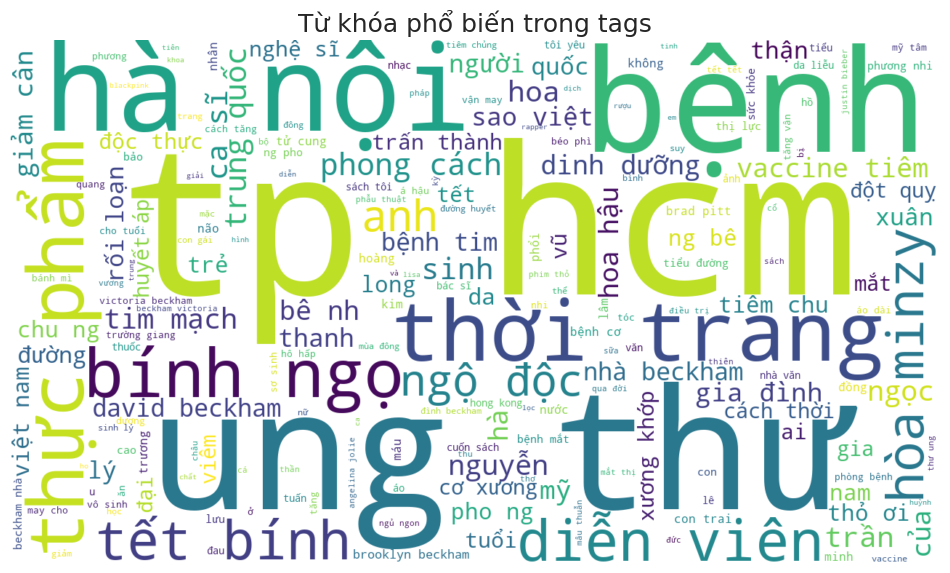

In [151]:

# all_tags = ', '.join([', '.df_clean['author_cleaned']])
all_tags = ', '.join(df_clean['tags'].astype(str).tolist())
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(width=1280, height=720, background_color='white', max_words=200, contour_width=3).generate(all_tags)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Từ khóa phổ biến trong tags', fontsize=18)
plt.show()

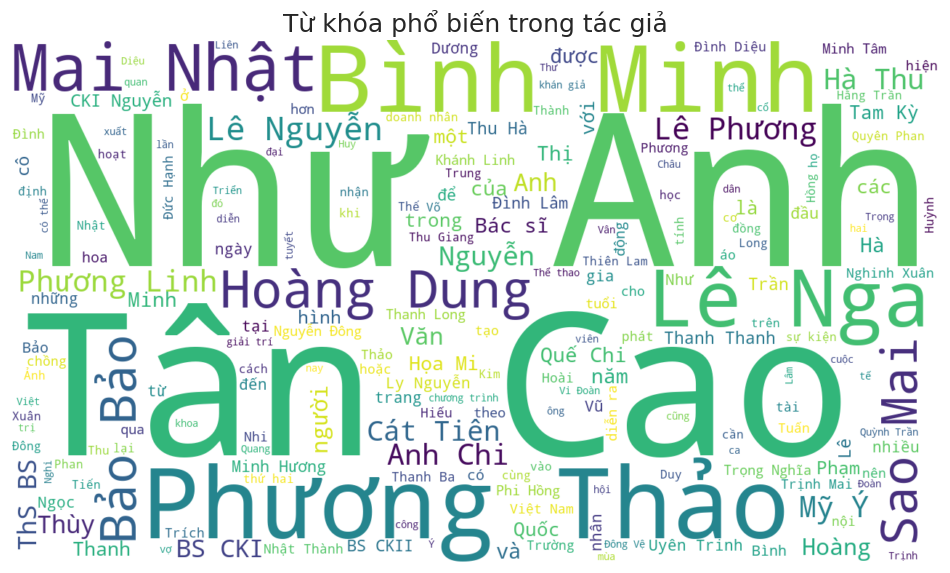

In [152]:

# all_tags = ', '.join([', '.df_CN_clean['author_cleaned']])
all_tags = ', '.join(df_clean['author'].astype(str).tolist())
plt.figure(figsize=(12, 8))
wordcloud = WordCloud(width=1280, height=720, background_color='white', max_words=200, contour_width=3).generate(all_tags)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Từ khóa phổ biến trong tác giả', fontsize=18)
plt.show()

## 9. Xử lý Outlier

In [153]:
# Xử lý Outlier với Nums_of_comments
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1214,2026-02-24 05:43:22.438220,2026-01-22 08:37:00,2026-02-16 02:59:15,2026-02-27 16:09:00,2026-03-06 19:00:00,2026-03-14 00:03:00,NaN
nums_of_comments,1214.0,7.578254,0.0,0.0,2.0,7.0,206.0,18.500553
content_length,1214.0,2832.425865,7.0,2030.0,2542.0,3303.5,10157.0,1339.401965
description_length,1214.0,132.98682,72.0,116.0,131.0,147.0,227.0,24.470144
title_length,1214.0,44.998353,16.0,38.0,44.0,52.0,80.0,10.886282
content_cleaned_length,1214.0,2753.11285,7.0,1976.75,2470.5,3200.75,9842.0,1299.44254
description_cleaned_length,1214.0,128.565898,71.0,112.0,126.0,142.0,220.0,24.140394
title_cleaned_length,1214.0,44.224053,16.0,37.0,44.0,51.0,79.0,10.660119
tags_count,1214.0,3.442339,1.0,2.0,3.0,4.0,16.0,1.653262
year,1214.0,2026.0,2026.0,2026.0,2026.0,2026.0,2026.0,0.0


## 9.1. Phân tích outlier trước khi xử lý

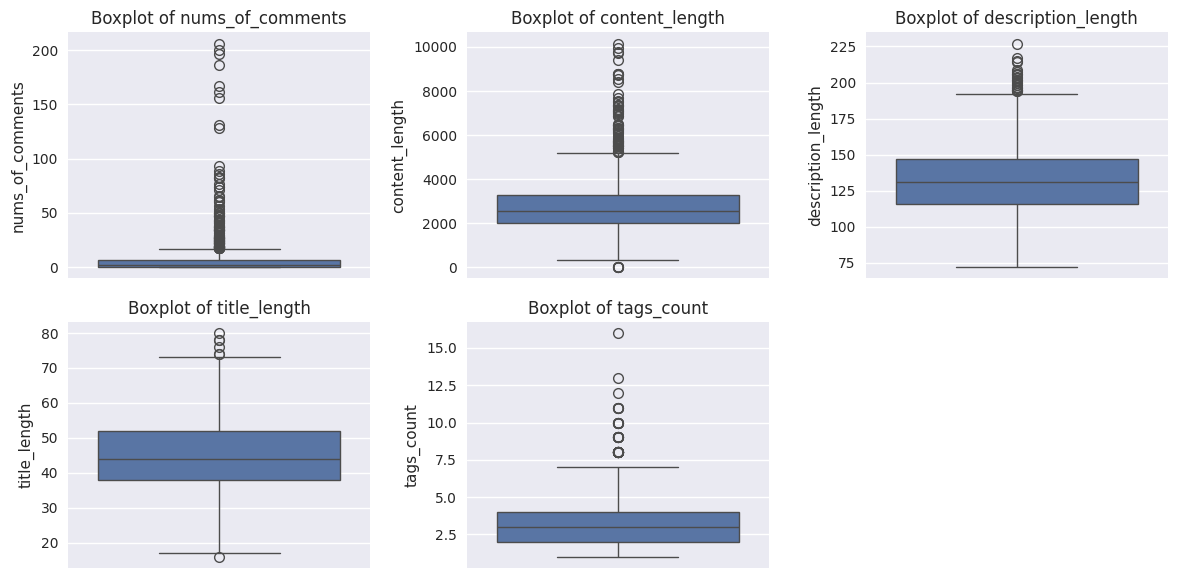

,column,min,max,mean,median,lower_bound,upper_bound,outliers_count,outliers_percent
0,nums_of_comments,0,206,7.578254,2.0,-10.50,17.50,124,10.214168
1,content_length,7,10157,2832.425865,2542.0,119.75,5213.75,71,5.848435
2,description_length,72,227,132.986820,131.0,69.50,193.50,26,2.141680
3,title_length,16,80,44.998353,44.0,17.00,73.00,7,0.576606
4,tags_count,1,16,3.442339,3.0,-1.00,7.00,39,3.212521


In [154]:
# Vẽ boxplot để phát hiện outlier trong các trường số
plt.figure(figsize=(12, 6))

# Các trường số liệu cần kiểm tra outlier
numeric_cols = ['nums_of_comments', 'content_length', 'description_length', 
                'title_length', 'tags_count']

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    
plt.show()

# Hiển thị thống kê chi tiết về các trường này
stats_df = pd.DataFrame()
for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)][col].count()
    outlier_percent = outliers / len(df_clean) * 100
    
    stats = {
        'column': col,
        'min': df_clean[col].min(),
        'max': df_clean[col].max(),
        'mean': df_clean[col].mean(),
        'median': df_clean[col].median(),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outliers_count': outliers,
        'outliers_percent': outlier_percent
    }
    stats_df = pd.concat([stats_df, pd.DataFrame([stats])], ignore_index=True)

stats_df

## 9.2. Xử lý outlier với nhiều phương pháp 

In [155]:
# Tạo bản sao để so sánh trước và sau khi xử lý
df_before_outlier = df_clean.copy()

# 1. Phương pháp 1: Cắt ngưỡng (Trimming/Capping)
def cap_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    df_capped = df.copy()
    # Convert to float to handle float bounds
    df_capped[column] = df_capped[column].astype(float)
    df_capped.loc[df_capped[column] < lower_bound, column] = lower_bound
    df_capped.loc[df_capped[column] > upper_bound, column] = upper_bound
    return df_capped

# 2. Phương pháp 2: Chuyển đổi logarit (Log transformation)
def log_transform(df, column):
    df_log = df.copy()
    # Thêm 1 để tránh log(0)
    df_log[f'{column}_log'] = np.log1p(df_log[column])
    return df_log

# 3. Phương pháp 3: Winsorization (thay thế bằng phân vị)
def winsorize(df, column, limits=[0.05, 0.05]):
    from scipy.stats.mstats import winsorize
    df_win = df.copy()
    df_win[column] = winsorize(df_win[column], limits=limits)
    return df_win

# Áp dụng các phương pháp xử lý outlier
df_capped = df_clean.copy()
for col in ['nums_of_comments', 'content_length']:
    df_capped = cap_outliers(df_capped, col)

# Hoặc winsorize
df_winsorized = df_clean.copy()
for col in ['nums_of_comments', 'content_length']:
    df_winsorized = winsorize(df_winsorized, col)

# Log transform cho các biến có phân phối lệch dương
df_log = df_clean.copy()
df_log['nums_of_comments_log'] = np.log1p(df_log['nums_of_comments'])

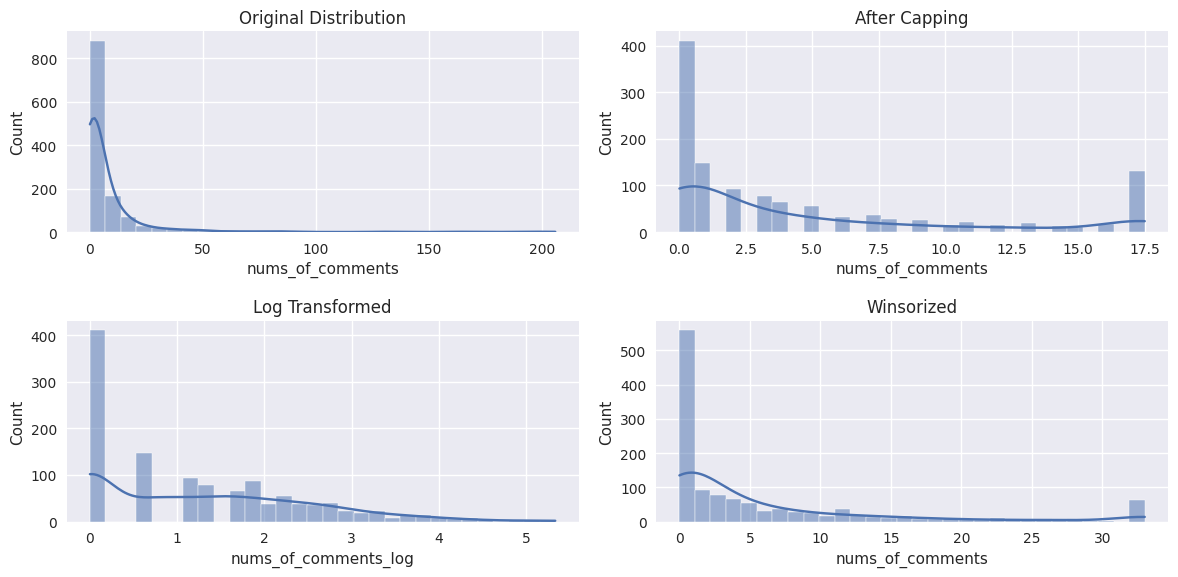

In [156]:
# So sánh phân phối trước và sau khi xử lý outlier
plt.figure(figsize=(12, 6))

# Ví dụ với 'nums_of_comments'
plt.subplot(2, 2, 1)
sns.histplot(df_clean['nums_of_comments'], kde=True, bins=30)
plt.title('Original Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df_capped['nums_of_comments'], kde=True, bins=30)
plt.title('After Capping')

plt.subplot(2, 2, 3)
sns.histplot(df_log['nums_of_comments_log'], kde=True, bins=30)
plt.title('Log Transformed')

plt.subplot(2, 2, 4)
sns.histplot(df_winsorized['nums_of_comments'], kde=True, bins=30)
plt.title('Winsorized')

plt.tight_layout()
plt.show()

## 10. Xuất data_clean

In [157]:
cols_final = ['title_cleaned_length', 'description_cleaned_length', 'content_cleaned_length', 'content_cleaned', 
              'title_cleaned', 'description_cleaned', 'tags_count', 'tags_list', 'category', 'nums_of_comments', 
              'hour', 'day_of_week', 'month', 'year', 'author_cleaned']

df_clean_final = df_clean[cols_final].copy()
df_clean_final['nums_of_comments'] = df_clean_final['nums_of_comments']
df_clean_final['tags_count'] = df_clean_final['tags_count']
df_clean_final['hour'] = df_clean_final['hour']
df_clean_final['day_of_week'] = df_clean_final['day_of_week']
df_clean_final['month'] = df_clean_final['month']
df_clean_final['year'] = df_clean_final['year']
df_clean_final['category'] = df_clean_final['category']
df_clean_final['author'] = df_clean_final['author_cleaned']
df_clean_final['tags_list'] = df_clean_final['tags_list']
df_clean_final['content'] = df_clean_final['content_cleaned']
df_clean_final['title'] = df_clean_final['title_cleaned']
df_clean_final['description'] = df_clean_final['description_cleaned']
df_clean_final['content_length'] = df_clean_final['content_cleaned_length']
df_clean_final['title_length'] = df_clean_final['title_cleaned_length']
df_clean_final['description_length'] = df_clean_final['description_cleaned_length']

In [158]:
df_clean_final.info()

<class 'pandas.DataFrame'>
Index: 1214 entries, 0 to 1218
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   title_cleaned_length        1214 non-null   int64 
 1   description_cleaned_length  1214 non-null   int64 
 2   content_cleaned_length      1214 non-null   int64 
 3   content_cleaned             1214 non-null   str   
 4   title_cleaned               1214 non-null   str   
 5   description_cleaned         1214 non-null   str   
 6   tags_count                  1214 non-null   int64 
 7   tags_list                   1214 non-null   object
 8   category                    1214 non-null   str   
 9   nums_of_comments            1214 non-null   int64 
 10  hour                        1214 non-null   int32 
 11  day_of_week                 1214 non-null   int32 
 12  month                       1214 non-null   int32 
 13  year                        1214 non-null   int32 
 14  author_c

## 11. Lưu dataset đã clean

In [159]:
df_clean_final.to_csv("../data/vnexpress_clean_data.csv", index=False)

print("Saved clean dataset")

Saved clean dataset
